In [ ]:
import numpy as np

def lorenz96(x, F=8.0):
    """
    Lorenz-96 model (cyclic indices).

    dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - x_i + F
    """
    N = len(x)
    dx = np.zeros(N)

    for i in range(N):
        dx[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F

    return dx


def simulate_l96(N=5, T=1000, dt=0.01, F=8.0, noise_std=0.0):
    """
    Simulate Lorenz-96 time series.

    Args:
        N: number of variables (dimensions)
        T: number of time steps
        dt: integration step size
        F: forcing constant (chaos ~8)
        noise_std: Gaussian noise level

    Returns:
        X: shape (T, N)
    """
    X = np.zeros((T, N))

    # initial condition (small perturbation)
    x = F * np.ones(N)
    x[0] += 0.01

    for t in range(T):
        # Runge-Kutta 4 (RK4)
        k1 = lorenz96(x, F)
        k2 = lorenz96(x + 0.5 * dt * k1, F)
        k3 = lorenz96(x + 0.5 * dt * k2, F)
        k4 = lorenz96(x + dt * k3, F)

        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if noise_std > 0:
            x += np.random.normal(0, noise_std, size=N)

        X[t] = x

    return X

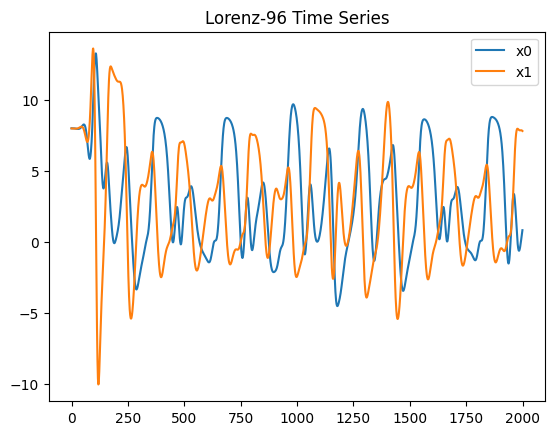

In [2]:
import matplotlib.pyplot as plt

X = simulate_l96(N=5, T=2000, dt=0.01, F=8.0)

plt.plot(X[:, 0], label="x0")
plt.plot(X[:, 1], label="x1")
plt.legend()
plt.title("Lorenz-96 Time Series")
plt.show()

In [ ]:
def make_windows(X, W):
    T, N = X.shape
    windows = []

    for t in range(W, T):
        windows.append((X[t-W:t], X[t]))

    return windows